<h2 style="text-align:center;"> HELLENIC OPEN UNIVERSITY - SCHOOL OF SCIENCE AND TECHNOLOGY</h2>
<h2 style="text-align:center;"> DATA SCIENCE AND MACHINE LEARNING : DAMA61 ACAD. YEAR 2025-26</h2>

<h3 style="text-align:center;"> WRITTEN ASSIGNMENT 1 - Solutions</h3>

<hr>

### Helpful configurations

In [1]:
# increase the width of the notebook
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

## Problem 1:

A very frequent problem in machine learning is predicting the value of a feature of an unknown set of samples, based on the remaining features with respect to a given dataset. This is performed by proper analysis of the predictors, i.e. the features that will be used as inputs to the model, and the labels which are the outputs of the model. An interesting use case is the MPG dataset available throuth Python <b>seaborn</b> package. The MPG dataset can be used to predict a car’s fuel efficiency (miles per gallon - MPG) based on various car attributes. This assignment requires the design and implementation of an end-to-end machine learning solution that adheres to the following:

1) Open a Jupyter-notebook and load the dataset. Inspect a few initial values. <b>[5%]</b>
2) Print the dataset by getting the info and pinpointing the predictors and target variables. What are the features influencing the fuel efficiency? <b>[5%]</b>
3) Compute the descriptive statistics of the dataset features and discuss about their types, ranges and completeness. <b>[5%]</b>
4) Clean the dataset, if needed, by removing lines with missing values. Moreover, remove categorical variables from the dataset. Form the histograms of the features and discuss their distribution. Can the distribution of some features, excluding targets, be improved (tending more towards the Gaussian) and how?. Apply these improvements to a copy of the dataframe, plot the histograms and comment about the outcome. <b>[15%]</b>
5) Which are the features that mostly affect quality and which are those that affect it less? Provide evidence through correlation and discuss accordingly. <b>[15%]</b>
6) Separate the predictor variables and targets. Split the dataset into a training and a testing set, retaining 80% and 20% of the total number of samples, respectively, using random shuffling. Fix random state to 42. Check the distribution of the targets in the training set and the test set using histograms with density for both, plotted in the same figure. What do you observe? Make sure that the histograms share the same number of bins (e.g. 10). <b>[20%]</b>
7) Create a pipeline composed of a standard scaler and linear regression. Evaluate the performance of the model, using the test set, with respect to the following metrics: R2-score, Mean Absolute Error, Mean Absolute Percentage Error and Mean Squared Error. Comment on the accuracy of predictions by plotting Actuals vs Predicted diagram. Comment on the results. <b>[20%]</b>
8) Perform 10-fold cross validation and compute the mean and standard deviation of the scores over the folds. Is the model’s R2-score within the limits defined by the 10-fold cross validation? Please comment. <b>[15%]</b>

<i>Hint: In order to install seaborn package you can include the command <b>!pip install seaborn</b> in your notebook.</i>

### Helpful imports

In [2]:
import numpy as np
import seaborn as sns

import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12})

### Question 1

In [3]:
# Load dataset
df = sns.load_dataset('mpg')

# Check a few samples
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


### Question 2

In [4]:
# Get info around the variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


#### Comment:

In [5]:
input_features = [k for k in df.keys() if k not in ['mpg']]
print(f"The dataset includes {len(input_features)} input features, namely: {', '.join(input_features)}.")

The dataset includes 8 input features, namely: cylinders, displacement, horsepower, weight, acceleration, model_year, origin, name.


### Question 3

In [6]:
# Some descriptive statistics around the samples with respect to the features of the dataset
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


#### Comment:

The dataset for mpg is composed of 398 samples and 6 out of them are missing the horsepower value. The displacement, horsepower and acceleration are 64-bit floating point numbers. The cylinders, weight and model_year are 64-bit integers. The origin and name are objects of type string. The target variable mpg is composed of 64-bit floating point numbers.

The ranges of numerical values vary significanlty in terms of mean and standard deviation. These very different ranges can introduce unwanted bias in the model. This can be partially mitigated by proper scaling of the data.

### Question 4

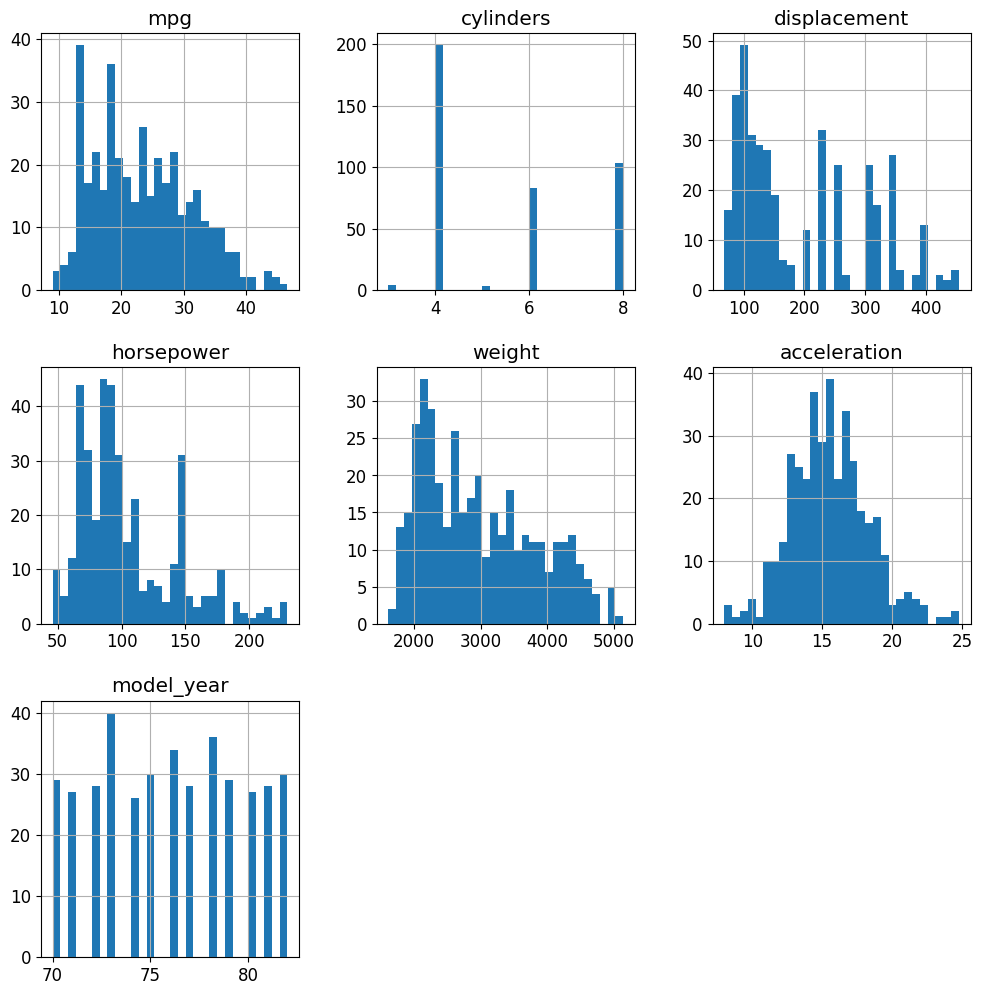

In [7]:
# Drop samples with nan values
df = df.dropna()

# Drop categorical variables
df = df.drop(columns=df.select_dtypes(include=['object', 'category']).columns) # or df = df.drop(columns=['name', 'origin'])

# Plot a histogram 
df.hist(bins=30, figsize=(12, 12))
plt.show()

#### Comment:

By computing and visualizing the distribution of each feature, we observe that some features such as the cylinders, displacement, horsepower, and weight have a right skewness (i.e., they do not follow a Gaussian distribution). This can be rectified by applying the log transform of these features. This is expected to improve accuracy of the model since it will render the transformed features closer to the Gaussian distribution. The acceleration follows closely a Gaussian distribution.

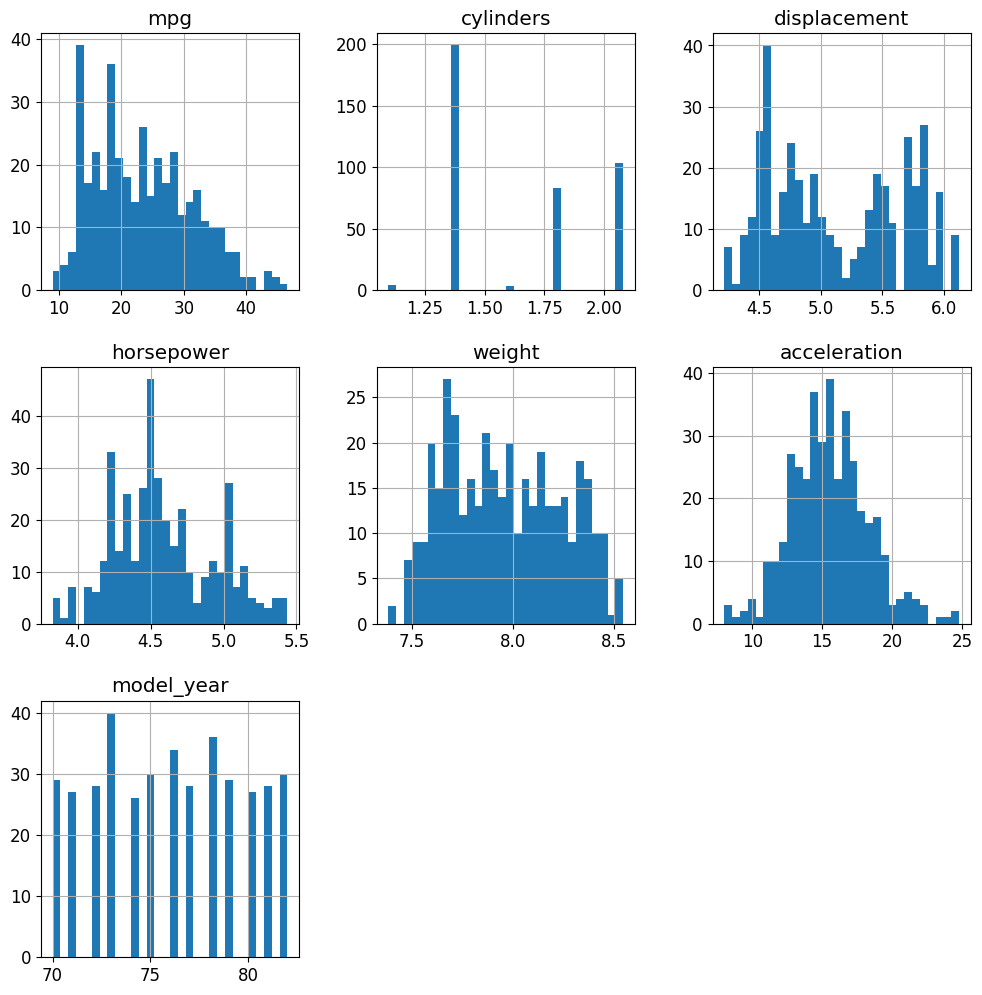

In [8]:
# Copy dataframe and apply transfor
df2 = df.copy()
df2["cylinders"] = np.log(df2["cylinders"])
df2["displacement"] = np.log(df2["displacement"])
df2["horsepower"] = np.log(df2["horsepower"])
df2["weight"] = np.log(df2["weight"])

# Plot histogram
df2.hist(bins=30, figsize=(12, 12))
plt.show()

#### Comment

We can observe that horsepower and weight have improved significantly towards the Gaussian distribution.

### Question 5

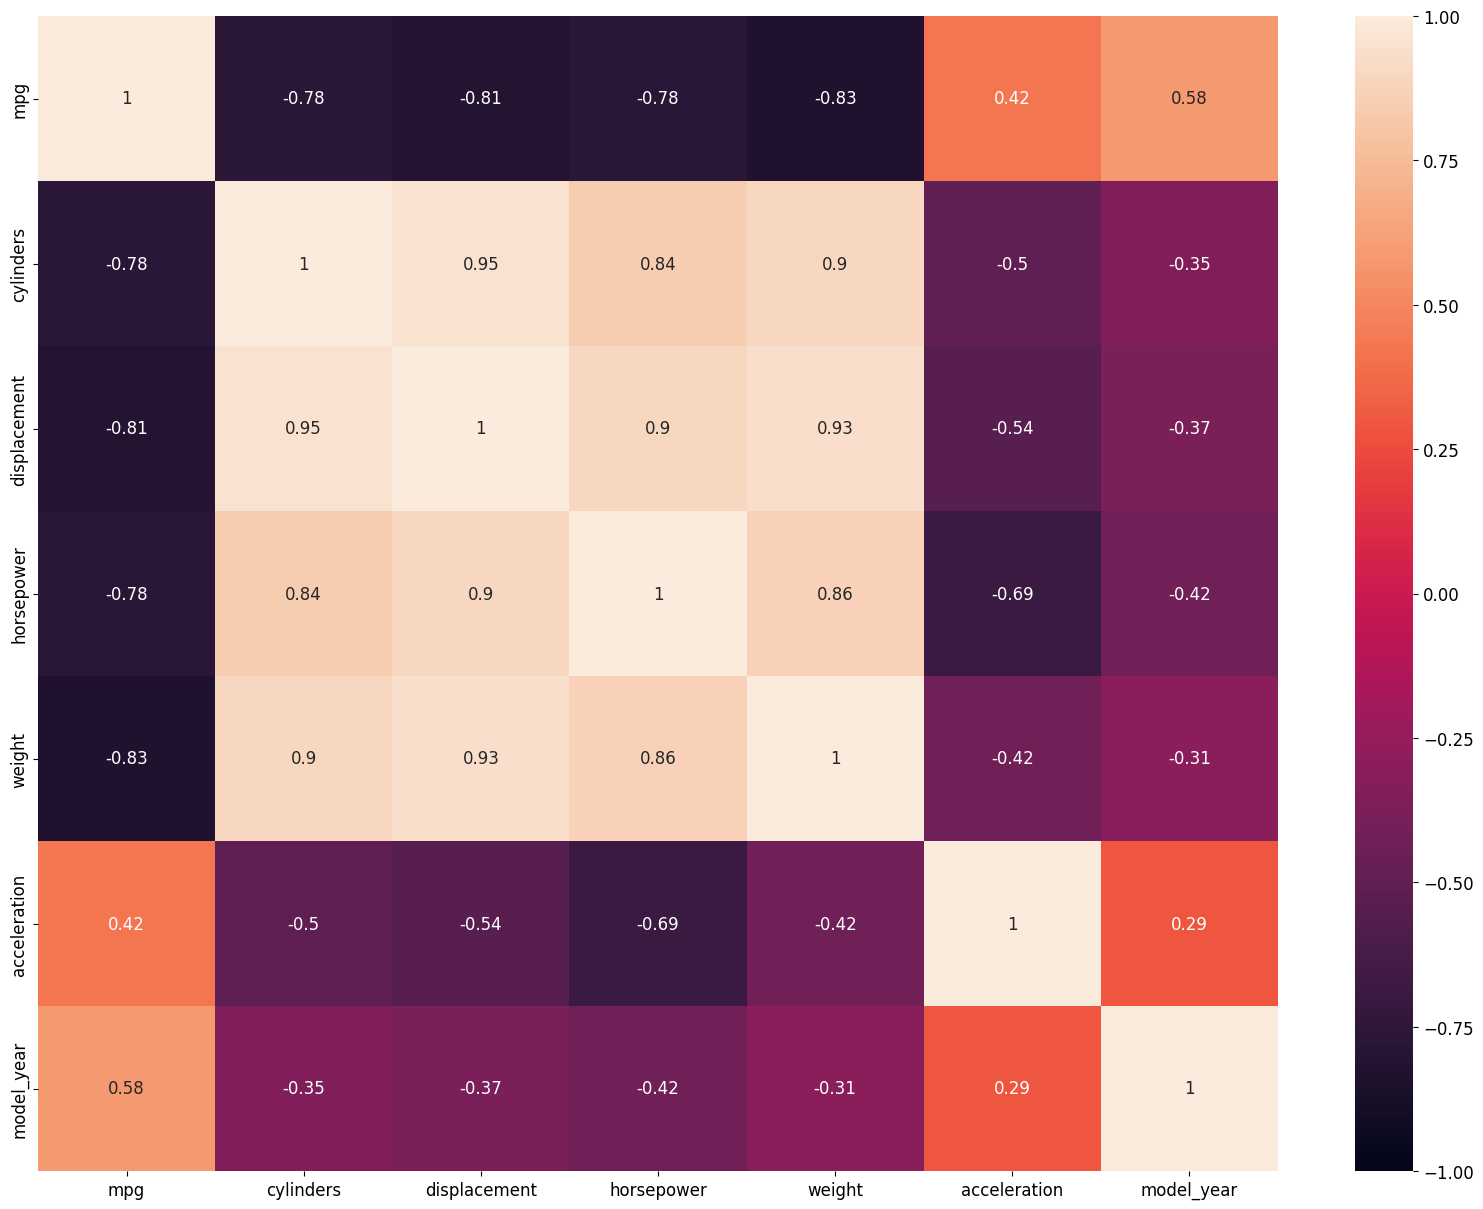

In [9]:
# A good indicator of the influence of a predictor to the output value is the correlation coefficient.

fig = plt.figure(figsize = (20,15))
sns.heatmap(df.corr(), vmin = -1, vmax = 1, annot = True)
plt.show()

#### Comment:

From the heatmap it is evident that weight, displacement, horsepower and cylinders have very high negative correlation with the target variable mpg. This means that an increase in the value of these features leads to decrease of the mpg significanlty. Thus, rendering the car less efficient. 

On the other hand model_year has increased positive correlation with mpg, while acceleration has mild positive correlation with mpg. These variables lead to increase of mpg when the value of any of them increases. Thus, rendering the car more efficient.

### Question 6

In [10]:
# Separate predictors and targets
X = df.drop(columns=['mpg'])  # predictors
y = df['mpg']                 # target variable

# Split data in training and test sets
# belonging to the test set
test_size = 0.2

# Split the dataset and fix random seed for reproducibility
from sklearn.model_selection import train_test_split

# Random spliting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle = True, random_state=42)

print(f"Number of samples in training set: {len(y_train)}")
print(f"Number of samples in test set: {len(y_test)}")

Number of samples in training set: 313
Number of samples in test set: 79


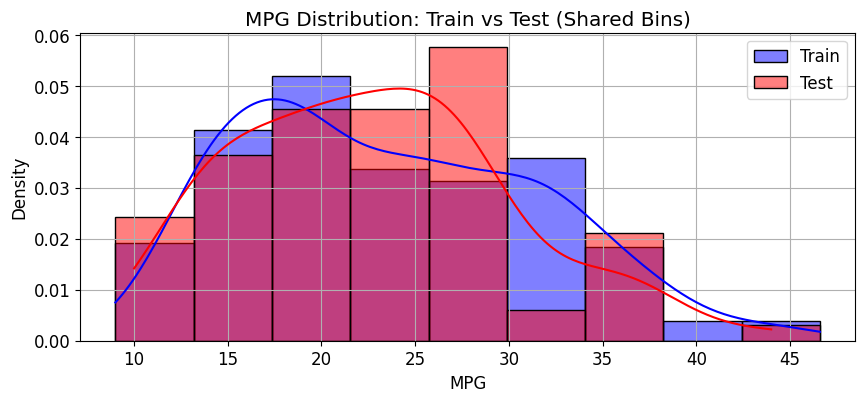

In [11]:
# Define shared bin edges across the range of y (mpg)
all_y = pd.concat([y_train, y_test])
bins = np.linspace(all_y.min(), all_y.max(), 10)  # 10 uniform bins

# Plot histograms with shared bins
plt.figure(figsize=(10, 4))
sns.histplot(y_train, kde=True, color='blue', label='Train', stat='density', bins=bins)
sns.histplot(y_test, kde=True, color='red', label='Test', stat='density', bins=bins)
plt.title("MPG Distribution: Train vs Test (Shared Bins)")
plt.xlabel("MPG")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()

#### Comments:
The two density distributions in the above histogram are almost similar, with the exception of the bins in the range 22 to 35. This might bias the model slightly during training.

### Question 7

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Fit the model on training data
pipeline.fit(X_train, y_train)

# Predict on test data
y_pred = pipeline.predict(X_test)

# Evaluate performance
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R2 Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape * 100:.2f}%")
print(f"Mean Squared Error (MSE): {mse:.2f}")


R2 Score: 0.7942
Mean Absolute Error (MAE): 2.50
Mean Absolute Percentage Error (MAPE): 12.29%
Mean Squared Error (MSE): 10.50


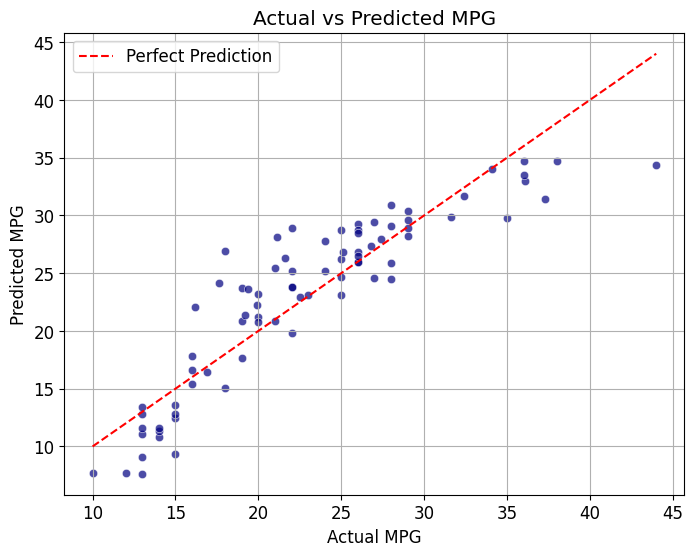

In [13]:
# Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='navy', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Actual vs Predicted MPG')
plt.legend()
plt.grid(True)
plt.show()


#### Comment:

The Actual vs Predicted MPG plot shows a generally strong linear alignment between the predicted values and the actual MPG values, indicating that the linear regression model captures the trend well. Most points cluster near the red dashed line (which represents perfect predictions), although there is some scatter and mild deviation, especially at the higher and lower ends of the MPG scale. This suggests the model may underfit slightly at the extremes. However, overall prediction accuracy appears good, and the residual spread is relatively narrow, reflecting a decent performance for a simple linear model. The underfit problem can be dealt with using a more powerful model.

### Question 8

In [14]:
from sklearn.model_selection import cross_val_score

# Perform 10-fold cross-validation using R2 scoring
cv_scores = cross_val_score(pipeline, X, y, cv=10, scoring='r2')

# Compute mean and standard deviation
mean_r2 = np.mean(cv_scores)
std_r2 = np.std(cv_scores)

print(f"10-Fold CV R2 Mean: {mean_r2:.4f}")
print(f"10-Fold CV R2 Std Dev: {std_r2:.4f}")

# Get lower and upper bounds
lower_bound = mean_r2 - std_r2
upper_bound = mean_r2 + std_r2

print(f"10-Fold CV R2 Lower bound: {lower_bound:.4f}")
print(f"10-Fold CV R2 Upper bound: {upper_bound:.4f}")

10-Fold CV R2 Mean: 0.6187
10-Fold CV R2 Std Dev: 0.2401
10-Fold CV R2 Lower bound: 0.3787
10-Fold CV R2 Upper bound: 0.8588


#### Comments:

The computed R<sup>2</sup> score is withing the range defined by the average CV score and corresponding standard deviation. More specifically, it is very close to the upper value. Thus, the splitting affects the accuracy significantly because it seems to be biasing the model.

<hr>

## Problem 2:

Work with the MNIST dataset and:
1. Load the data and split it into training (60,000 images) and test sets (10,000 images). Ensure that pixel values are normalized between 0 and 1. <b>[10%]</b>
2. Convert the dataset into a binary classification task: label images as “odd” (class 1) or “even” (class 0), with zero included in the even class. <b>[10%]</b>
3. Use a KNeighborsClassifier and perform hyperparameter tuning using grid search on n_neighbors, testing values 3, 5, and 7. <b>[20%]</b>
4. Evaluate the model’s performance on the test set in terms of accuracy, precision, and recall, using 3-fold cross-validation. <b>[30%]</b>
5. Calculate the confusion matrix for the training set. How many training samples were misclassified as odd, and how many as even? <b>[15%]</b>
6. Plot the ROC curve and calculate the area under the curve (AUC).<b>[15%]</b>

### Question 1

In [15]:
from sklearn.datasets import fetch_openml
import numpy as np

# Load MNIST dataset
mnist = fetch_openml('mnist_784', as_frame=False, parser="auto")

# Split into training and test sets
X_train, y_train = mnist.data[:60000], mnist.target[:60000]
X_test, y_test = mnist.data[60000:], mnist.target[60000:]

In [16]:
X_train.min(), X_train.max()

(0, 255)

In [17]:
# Normalize pixel values to 0-1 range
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

### Question 2

In [18]:
from numpy import where

# Convert labels to binary: "odd" (1) and "even" (0), with zero included in even
y_train_binary = where(y_train.astype(int) % 2 == 1, 1, 0).astype(int)
y_test_binary = where(y_test.astype(int) % 2 == 1, 1, 0).astype(int)

### Question 3

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Define hyperparameter grid for tuning
param_grid = {'n_neighbors': [3, 5, 7]}

# Initialize the classifier and perform grid search
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=3)
grid_search.fit(X_train.reshape(-1, 784), y_train_binary)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'n_neighbors': 3}


### Question 4

In [20]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score

# Define metrics to evaluate
metrics = {
    'Accuracy': make_scorer(accuracy_score),
    'Precision': make_scorer(precision_score),
    'Recall': make_scorer(recall_score)
}

# Perform cross-validation for each metric
for name, scorer in metrics.items():
    scores = cross_val_score(grid_search.best_estimator_, X_train.reshape(-1, 784), y_train_binary, cv=3, scoring=scorer)
    print(f"{name}: {scores.mean():.3f} ± {scores.std():.3f}")

# Evaluate on the test set
y_pred_test = grid_search.best_estimator_.predict(X_test.reshape(-1, 784))

print("\nTest Set Metrics:")
print(f"Accuracy: {accuracy_score(y_test_binary, y_pred_test):.3f}")
print(f"Precision: {precision_score(y_test_binary, y_pred_test):.3f}")
print(f"Recall: {recall_score(y_test_binary, y_pred_test):.3f}")


Accuracy: 0.982 ± 0.001
Precision: 0.976 ± 0.001
Recall: 0.990 ± 0.001

Test Set Metrics:
Accuracy: 0.985
Precision: 0.980
Recall: 0.991


### Question 5

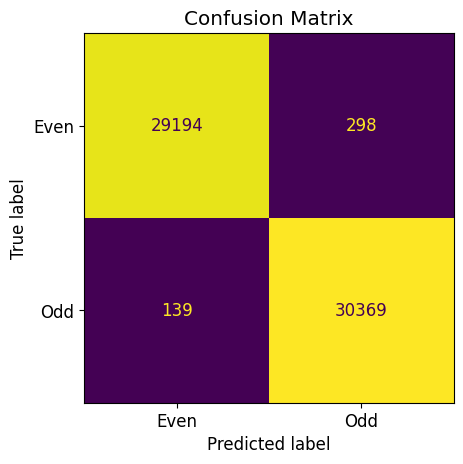


Misclassified as Odd: 298
Misclassified as Even: 139


In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict on training set
y_pred_train = grid_search.best_estimator_.predict(X_train.reshape(-1, 784))

# Calculate the confusion matrix
cm = confusion_matrix(y_train_binary, y_pred_train)

# Plot the confusion matrix
display_cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=['Even', 'Odd'])
display_cm.plot(values_format = 'd', colorbar = False)
plt.title("Confusion Matrix")
plt.show()

print(f"\nMisclassified as Odd: {cm[0][1]}")
print(f"Misclassified as Even: {cm[1][0]}")

### Question 6

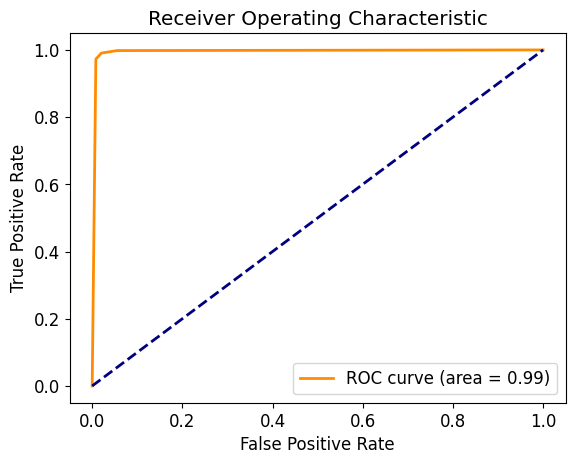


Area Under the Curve (AUC): 0.994


In [22]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities for test set
y_scores = grid_search.best_estimator_.predict_proba(X_test.reshape(-1, 784))[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_binary, y_scores)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

print(f"\nArea Under the Curve (AUC): {roc_auc:.3f}")